In [1]:
!pip -q install tokenizers transformers datasets scikit-learn matplotlib pandas tensorflow tensorflow_hub umap-learn


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Sample corpus we'll train our small tokenizers on.
# (In practice you'd use a much larger corpus - this is just for a quick, visualizable demo.)
corpus = [
    "The quick brown fox jumps over the lazy dog.",
    "Natural language processing is a fascinating field of artificial intelligence.",
    "Tokenization breaks text into smaller pieces called tokens.",
    "Subword tokenization handles rare and out-of-vocabulary words gracefully.",
    "The bank raised interest rates to control inflation.",
    "We sat by the river bank and watched the sunset.",
    "I need to bank this check before the branch closes.",
    "The bat flew out of the cave at dusk.",
    "He swung the bat and hit a home run.",
    "Deep learning models like BERT, GPT, and ELMo revolutionized NLP.",
    "Unhappiness and disagreement are common in unpredictable situations.",
    "Emoji like 😀 and 🌍 show up in real-world text all the time.",
]

with open("corpus.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(corpus))

corpus[:3]


['The quick brown fox jumps over the lazy dog.',
 'Natural language processing is a fascinating field of artificial intelligence.',
 'Tokenization breaks text into smaller pieces called tokens.']

## 1. BPE (Byte-Pair Encoding)

BPE starts from individual characters and **greedily merges the most frequent adjacent pair**
of symbols, over and over, until it hits the target vocab size. The merge rule is pure frequency.

In [3]:
## 1. BPE (Byte-Pair Encoding)

from tokenizers import Tokenizer, models, trainers, pre_tokenizers

bpe_tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))
bpe_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

bpe_trainer = trainers.BpeTrainer(
    vocab_size=300,
    min_frequency=1,
    special_tokens=["[UNK]", "[PAD]"]
)
bpe_tokenizer.train(["corpus.txt"], bpe_trainer)

print(f"BPE vocab size: {bpe_tokenizer.get_vocab_size()}")


BPE vocab size: 300


In [4]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

bpe_tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))
bpe_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

bpe_trainer = trainers.BpeTrainer(
    vocab_size=300,
    min_frequency=1,
    special_tokens=["[UNK]", "[PAD]"]
)
bpe_tokenizer.train(["corpus.txt"], bpe_trainer)

print(f"BPE vocab size: {bpe_tokenizer.get_vocab_size()}")


BPE vocab size: 300


In [5]:
def show_tokens(tokenizer, sentence, name=""):
    enc = tokenizer.encode(sentence)
    print(f"[{name}] {sentence}")
    print("  tokens:", enc.tokens)
    print("  count :", len(enc.tokens))
    print()
    return enc.tokens

test_sentences = [
    "Unhappiness and disagreement are common.",
    "The bank raised interest rates.",
    "Tokenization is fascinating!",
]

bpe_outputs = [show_tokens(bpe_tokenizer, s, "BPE") for s in test_sentences]


[BPE] Unhappiness and disagreement are common.
  tokens: ['Unhap', 'piness', 'and', 'disagreem', 'ent', 'are', 'comm', 'on', '.']
  count : 9

[BPE] The bank raised interest rates.
  tokens: ['The', 'bank', 'raised', 'interest', 'rates', '.']
  count : 6

[BPE] Tokenization is fascinating!
  tokens: ['Tokenization', 'is', 'fascinating', '[UNK]']
  count : 4



## 2. WordPiece

WordPiece also merges pairs bottom-up, but instead of raw frequency it picks the pair that
**maximizes the likelihood of the training corpus**:

```
score(pair) = freq(pair) / (freq(first) * freq(second))
```

This favors pairs that co-occur *more than you'd expect by chance*, not just pairs that are common.
Non-initial subword pieces get a `##` prefix (BERT-style) so you can tell where a word was split.


In [6]:
wp_tokenizer = Tokenizer(models.WordPiece(unk_token="[UNK]"))
wp_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

wp_trainer = trainers.WordPieceTrainer(
    vocab_size=300,
    min_frequency=1,
    special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]"]
)
wp_tokenizer.train(["corpus.txt"], wp_trainer)

print(f"WordPiece vocab size: {wp_tokenizer.get_vocab_size()}")
wp_outputs = [show_tokens(wp_tokenizer, s, "WordPiece") for s in test_sentences]


WordPiece vocab size: 300
[WordPiece] Unhappiness and disagreement are common.
  tokens: ['Un', '##hap', '##pin', '##ess', 'and', 'dis', '##agreem', '##ent', 'are', 'com', '##mon', '.']
  count : 12

[WordPiece] The bank raised interest rates.
  tokens: ['The', 'bank', 'raised', 'interest', 'rat', '##es', '.']
  count : 7

[WordPiece] Tokenization is fascinating!
  tokens: ['To', '##kenization', 'is', 'fa', '##sc', '##inating', '[UNK]']
  count : 7



## 3. Byte-Level BPE (GPT-2 style)

Same merge *algorithm* as BPE, but the starting alphabet is the **256 raw bytes** instead of
Unicode characters. This means it can represent *any* text — emoji, any language, weird symbols —
with zero `[UNK]` tokens, because everything is bytes underneath.


In [7]:
from tokenizers import ByteLevelBPETokenizer

blbpe_tokenizer = ByteLevelBPETokenizer()
blbpe_tokenizer.train(files=["corpus.txt"], vocab_size=300, min_frequency=1)

emoji_sentences = test_sentences + ["Emoji like 😀 and 🌍 show up in real text."]

for s in emoji_sentences:
    enc = blbpe_tokenizer.encode(s)
    print(f"[Byte-BPE] {s}")
    print("  tokens:", enc.tokens)
    print("  count :", len(enc.tokens))
    print()


[Byte-BPE] Unhappiness and disagreement are common.
  tokens: ['U', 'n', 'h', 'a', 'p', 'p', 'in', 'es', 's', 'Ġand', 'Ġd', 'is', 'a', 'g', 're', 'e', 'm', 'en', 't', 'Ġa', 're', 'Ġc', 'o', 'm', 'm', 'on', '.']
  count : 27

[Byte-BPE] The bank raised interest rates.
  tokens: ['The', 'Ġbank', 'Ġr', 'a', 'is', 'ed', 'Ġin', 't', 'e', 're', 's', 't', 'Ġr', 'at', 'es', '.']
  count : 16

[Byte-BPE] Tokenization is fascinating!
  tokens: ['T', 'o', 'ken', 'iz', 'ation', 'Ġ', 'is', 'Ġf', 'a', 's', 'c', 'in', 'at', 'ing', '!']
  count : 15

[Byte-BPE] Emoji like 😀 and 🌍 show up in real text.
  tokens: ['E', 'm', 'o', 'j', 'i', 'Ġl', 'i', 'k', 'e', 'Ġ', 'ð', 'Ł', 'ĺ', 'Ģ', 'Ġand', 'Ġ', 'ð', 'Ł', 'Į', 'į', 'Ġs', 'h', 'o', 'w', 'Ġ', 'u', 'p', 'Ġin', 'Ġ', 're', 'al', 'Ġt', 'e', 'x', 't', '.']
  count : 36



## 4. Side-by-Side Comparison

In [8]:
rows = []
for s in test_sentences:
    rows.append({
        "sentence": s,
        "BPE": " | ".join(show_tokens.__wrapped__(s) if False else bpe_tokenizer.encode(s).tokens),
        "WordPiece": " | ".join(wp_tokenizer.encode(s).tokens),
        "Byte-Level BPE": " | ".join(blbpe_tokenizer.encode(s).tokens),
    })

df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", None)
df


,sentence,BPE,WordPiece,Byte-Level BPE
0,Unhappiness and disagreement are common.,Unhap | piness | and | disagreem | ent | are | comm | on | .,Un | ##hap | ##pin | ##ess | and | dis | ##agreem | ##ent | are | com | ##mon | .,U | n | h | a | p | p | in | es | s | Ġand | Ġd | is | a | g | re | e | m | en | t | Ġa | re | Ġc | o | m | m | on | .
1,The bank raised interest rates.,The | bank | raised | interest | rates | .,The | bank | raised | interest | rat | ##es | .,The | Ġbank | Ġr | a | is | ed | Ġin | t | e | re | s | t | Ġr | at | es | .
2,Tokenization is fascinating!,Tokenization | is | fascinating | [UNK],To | ##kenization | is | fa | ##sc | ##inating | [UNK],T | o | ken | iz | ation | Ġ | is | Ġf | a | s | c | in | at | ing | !


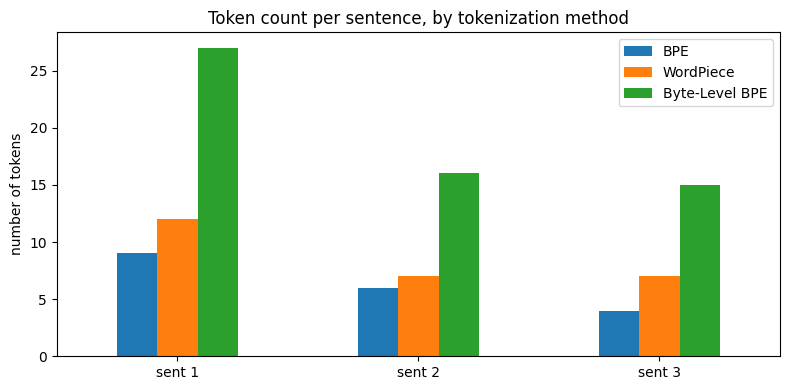

In [9]:
# Token-count comparison chart
counts = {
    "BPE": [len(bpe_tokenizer.encode(s).tokens) for s in test_sentences],
    "WordPiece": [len(wp_tokenizer.encode(s).tokens) for s in test_sentences],
    "Byte-Level BPE": [len(blbpe_tokenizer.encode(s).tokens) for s in test_sentences],
}
count_df = pd.DataFrame(counts, index=[f"sent {i+1}" for i in range(len(test_sentences))])
count_df.plot(kind="bar", figsize=(8, 4))
plt.title("Token count per sentence, by tokenization method")
plt.ylabel("number of tokens")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
